# 第五章：神經網路剪枝（Neural Network Pruning）

## 論文：Keeping Neural Networks Simple by Minimizing the Description Length of the Weights

**作者**：Geoffrey E. Hinton, Drew Van Camp (1993)

本 notebook 使用 PyTorch 實作神經網路剪枝技術，包括：
- 基於幅度的剪枝（Magnitude-based Pruning）
- 漸進式剪枝（Iterative Pruning）
- 結構化剪枝（Structured Pruning）
- MDL 原則驗證

In [1]:
# 跨平台中文字型設定（支援 Colab、VSCode、Antigravity 等本地環境）
import subprocess
import os
import shutil
import platform

system = platform.system()

# 必須在 import matplotlib 之前清除快取
cache_dir = os.path.expanduser('~/.matplotlib')
if os.path.exists(cache_dir):
    for f in os.listdir(cache_dir):
        if f.startswith('fontlist'):
            try:
                os.remove(os.path.join(cache_dir, f))
            except:
                pass

cache_dir2 = os.path.expanduser('~/.cache/matplotlib')
if os.path.exists(cache_dir2):
    shutil.rmtree(cache_dir2, ignore_errors=True)

# Linux/Colab 環境安裝中文字型
if system == 'Linux' or 'COLAB_GPU' in os.environ or os.path.exists('/content'):
    try:
        result = subprocess.run(['fc-list', ':lang=zh'], capture_output=True, text=True)
        if 'Noto Sans CJK' not in result.stdout:
            print("正在安裝中文字型...")
            subprocess.run(['apt-get', 'update', '-qq'], capture_output=True)
            subprocess.run(['apt-get', 'install', '-qq', '-y', 'fonts-noto-cjk'], capture_output=True)
            print("中文字型安裝完成，請重新啟動 kernel")
    except:
        pass

print(f"✓ {system} 環境")

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.nn.utils.prune as prune
import numpy as np
import matplotlib.pyplot as plt

# 重建字型快取並設定中文字型
from matplotlib.font_manager import fontManager
fontManager.__init__()

chinese_fonts = [
    'Heiti TC', 'PingFang TC', 'Noto Sans CJK TC',
    'Heiti SC', 'PingFang SC', 'Noto Sans CJK SC', 
    'Microsoft JhengHei', 'Microsoft YaHei',
    'SimHei', 'WenQuanYi Micro Hei', 'Arial Unicode MS',
]

available_fonts = set(f.name for f in fontManager.ttflist)
selected_font = None
for font in chinese_fonts:
    if font in available_fonts:
        selected_font = font
        break

if selected_font:
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = [selected_font] + chinese_fonts
    plt.rcParams['axes.unicode_minus'] = False
    print(f"✓ 使用中文字型: {selected_font}")
else:
    plt.rcParams['font.sans-serif'] = chinese_fonts
    plt.rcParams['axes.unicode_minus'] = False
    print("⚠ 使用預設字型列表")

import copy

# 執行跨平台字型設定
setup_chinese_font()

# 跨平台中文字型優先順序
chinese_fonts = [
    'Noto Sans CJK TC',      # Linux/Colab/Mac(安裝後) 繁體
    'Noto Sans CJK SC',      # Linux/Colab/Mac(安裝後) 簡體
    'Heiti TC',              # Mac 內建 繁體
    'Heiti SC',              # Mac 內建 簡體
    'PingFang TC',           # Mac 內建 繁體
    'PingFang SC',           # Mac 內建 簡體
    'Microsoft JhengHei',    # Windows 微軟正黑體 繁體
    'Microsoft YaHei',       # Windows 微軟雅黑 簡體
    'SimHei',                # Windows 黑體
    'WenQuanYi Micro Hei',   # Linux 文泉驛微米黑
    'Droid Sans Fallback',   # Android/舊版 Linux
    'Arial Unicode MS',      # 跨平台 Unicode 字型
    'DejaVu Sans',           # 後備字型
]

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = chinese_fonts
plt.rcParams['axes.unicode_minus'] = False

# 驗證可用字型
from matplotlib.font_manager import FontManager
fm = FontManager()
available_fonts = set(f.name for f in fm.ttflist)
for font in chinese_fonts:
    if font in available_fonts:
        print(f"✓ 使用中文字型: {font}")
        break

# 設定隨機種子
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch 版本: {torch.__version__}")
print(f"使用裝置：{device}")

✓ Darwin 環境


Matplotlib is building the font cache; this may take a moment.


✓ 使用中文字型: Heiti TC
PyTorch 版本: 2.9.1
使用裝置：cpu


## 1. 建立簡單的神經網路

In [3]:
class SimpleNN(nn.Module):
    """簡單的三層全連接神經網路"""
    
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x
    
    def count_parameters(self):
        """計算總參數和非零參數數量"""
        total = 0
        nonzero = 0
        for name, param in self.named_parameters():
            total += param.numel()
            nonzero += (param != 0).sum().item()
        return total, nonzero
    
    def get_sparsity(self):
        """計算稀疏度（零權重比例）"""
        total, nonzero = self.count_parameters()
        return 1 - (nonzero / total)

# 測試網路
model = SimpleNN(input_dim=20, hidden_dim=100, output_dim=10).to(device)
total, nonzero = model.count_parameters()
print(f"網路參數：{total} 總計, {nonzero} 非零")
print(f"初始稀疏度：{model.get_sparsity():.2%}")

網路參數：13210 總計, 13210 非零
初始稀疏度：0.00%


## 2. 生成合成資料集

In [4]:
def generate_classification_data(n_samples, n_features, n_classes):
    """生成多類別分類資料集"""
    X = []
    y = []
    samples_per_class = n_samples // n_classes
    
    for c in range(n_classes):
        # 每個類別有不同的中心
        center = np.random.randn(n_features) * 3
        X_class = np.random.randn(samples_per_class, n_features) * 0.5 + center
        y_class = np.full(samples_per_class, c)
        X.append(X_class)
        y.append(y_class)
    
    X = np.vstack(X).astype(np.float32)
    y = np.concatenate(y).astype(np.int64)
    
    # 打亂資料
    indices = np.random.permutation(len(X))
    return torch.tensor(X[indices]), torch.tensor(y[indices])

# 生成訓練和測試資料
X_train, y_train = generate_classification_data(2000, 20, 10)
X_test, y_test = generate_classification_data(500, 20, 10)

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

print(f"訓練集：{X_train.shape}")
print(f"測試集：{X_test.shape}")
print(f"類別數：{len(torch.unique(y_train))}")

訓練集：torch.Size([2000, 20])
測試集：torch.Size([500, 20])
類別數：10


## 3. 訓練函數

In [5]:
def train_model(model, X_train, y_train, X_test, y_test, 
                epochs=100, lr=0.01, verbose=True):
    """訓練模型"""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    train_losses = []
    test_accs = []
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
        
        train_losses.append(loss.item())
        
        # 評估
        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test)
            test_pred = test_outputs.argmax(dim=1)
            test_acc = (test_pred == y_test).float().mean().item()
            test_accs.append(test_acc)
        
        if verbose and (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}, Test Acc: {test_acc:.2%}")
    
    return train_losses, test_accs

def evaluate_model(model, X_test, y_test):
    """評估模型準確率"""
    model.eval()
    with torch.no_grad():
        outputs = model(X_test)
        pred = outputs.argmax(dim=1)
        acc = (pred == y_test).float().mean().item()
    return acc

## 4. 訓練基準模型

In [6]:
print("訓練基準模型...\n")
baseline_model = SimpleNN(20, 100, 10).to(device)
train_losses, test_accs = train_model(baseline_model, X_train, y_train, X_test, y_test, epochs=100)

baseline_acc = evaluate_model(baseline_model, X_test, y_test)
total_params, _ = baseline_model.count_parameters()
print(f"\n基準模型：{baseline_acc:.2%} 準確率, {total_params} 參數")

訓練基準模型...

Epoch 20/100, Loss: 0.0000, Test Acc: 0.60%
Epoch 40/100, Loss: 0.0000, Test Acc: 1.00%
Epoch 60/100, Loss: 0.0000, Test Acc: 1.00%
Epoch 80/100, Loss: 0.0000, Test Acc: 1.00%
Epoch 100/100, Loss: 0.0000, Test Acc: 1.00%

基準模型：1.00% 準確率, 13210 參數


## 5. 手動實作基於幅度的剪枝

In [7]:
class MagnitudePruner:
    """基於幅度的剪枝器"""
    
    @staticmethod
    def get_all_weights(model):
        """收集所有權重"""
        weights = []
        for name, param in model.named_parameters():
            if 'weight' in name:  # 只考慮權重，不考慮偏置
                weights.append(param.data.abs().flatten())
        return torch.cat(weights)
    
    @staticmethod
    def prune_by_magnitude(model, sparsity):
        """
        根據幅度剪枝權重
        
        Args:
            model: 要剪枝的模型
            sparsity: 目標稀疏度 (0-1)
        """
        # 收集所有權重的絕對值
        all_weights = MagnitudePruner.get_all_weights(model)
        
        # 計算閾值
        k = int(sparsity * len(all_weights))
        if k > 0:
            threshold = torch.kthvalue(all_weights, k).values.item()
        else:
            threshold = 0
        
        # 應用剪枝
        pruned_count = 0
        total_count = 0
        for name, param in model.named_parameters():
            if 'weight' in name:
                mask = param.data.abs() > threshold
                pruned_count += (~mask).sum().item()
                total_count += param.numel()
                param.data *= mask.float()
        
        actual_sparsity = pruned_count / total_count
        return threshold, actual_sparsity

# 測試剪枝
pruned_model = copy.deepcopy(baseline_model)

print("剪枝前：")
acc_before = evaluate_model(pruned_model, X_test, y_test)
print(f"準確率：{acc_before:.2%}")
print(f"稀疏度：{pruned_model.get_sparsity():.2%}\n")

print("剪枝 50% 的權重...")
threshold, actual_sparsity = MagnitudePruner.prune_by_magnitude(pruned_model, sparsity=0.5)
print(f"閾值：{threshold:.6f}")
print(f"實際稀疏度：{actual_sparsity:.2%}\n")

print("剪枝後（微調前）：")
acc_after = evaluate_model(pruned_model, X_test, y_test)
print(f"準確率：{acc_after:.2%}")
print(f"準確率下降：{(acc_before - acc_after):.2%}")

剪枝前：
準確率：1.00%
稀疏度：0.00%

剪枝 50% 的權重...
閾值：0.088352
實際稀疏度：50.00%

剪枝後（微調前）：
準確率：0.80%
準確率下降：0.20%


## 6. 剪枝後微調

In [8]:
def finetune_pruned_model(model, X_train, y_train, X_test, y_test, 
                          epochs=50, lr=0.001):
    """
    微調剪枝後的模型
    注意：在更新後將被剪枝的權重保持為零
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    # 記錄哪些權重被剪枝（為零）
    masks = {}
    for name, param in model.named_parameters():
        if 'weight' in name:
            masks[name] = (param.data != 0).float()
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
        
        # 重新應用遮罩（保持被剪枝的權重為零）
        with torch.no_grad():
            for name, param in model.named_parameters():
                if name in masks:
                    param.data *= masks[name]
    
    return evaluate_model(model, X_test, y_test)

print("微調剪枝後的模型...\n")
acc_finetuned = finetune_pruned_model(pruned_model, X_train, y_train, X_test, y_test)

print(f"\n{'='*60}")
print("結果比較：")
print(f"{'='*60}")
print(f"基準模型：    {baseline_acc:.2%} 準確率, {total_params} 參數")
total, nonzero = pruned_model.count_parameters()
print(f"剪枝 50%：    {acc_finetuned:.2%} 準確率, ~{nonzero} 活躍參數")
print(f"壓縮率：      {total_params/nonzero:.2f}x")
print(f"準確率變化：  {(acc_finetuned - baseline_acc):+.2%}")
print(f"{'='*60}")

微調剪枝後的模型...


結果比較：
基準模型：    1.00% 準確率, 13210 參數
剪枝 50%：    0.20% 準確率, ~6710 活躍參數
壓縮率：      1.97x
準確率變化：  -0.80%


## 7. 使用 PyTorch 內建的剪枝工具

In [9]:
def apply_pytorch_pruning(model, amount=0.5):
    """
    使用 PyTorch 內建的剪枝功能
    
    Args:
        model: 要剪枝的模型
        amount: 每層要剪枝的比例
    """
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            # L1 非結構化剪枝（基於幅度）
            prune.l1_unstructured(module, name='weight', amount=amount)
    
    return model

def get_pruning_stats(model):
    """獲取剪枝統計資訊"""
    total_zeros = 0
    total_elements = 0
    
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            if hasattr(module, 'weight_mask'):
                zeros = (module.weight_mask == 0).sum().item()
                elements = module.weight_mask.numel()
            else:
                zeros = (module.weight == 0).sum().item()
                elements = module.weight.numel()
            total_zeros += zeros
            total_elements += elements
            print(f"  {name}.weight: {zeros}/{elements} = {zeros/elements:.2%} 稀疏")
    
    print(f"  總計: {total_zeros}/{total_elements} = {total_zeros/total_elements:.2%} 稀疏")
    return total_zeros / total_elements

# 建立新模型並使用 PyTorch 剪枝
pytorch_pruned = copy.deepcopy(baseline_model)

print("使用 PyTorch 內建剪枝...\n")
apply_pytorch_pruning(pytorch_pruned, amount=0.5)

print("剪枝統計：")
sparsity = get_pruning_stats(pytorch_pruned)

print(f"\n剪枝後準確率：{evaluate_model(pytorch_pruned, X_test, y_test):.2%}")

使用 PyTorch 內建剪枝...

剪枝統計：
  fc1.weight: 1000/2000 = 50.00% 稀疏
  fc2.weight: 5000/10000 = 50.00% 稀疏
  fc3.weight: 500/1000 = 50.00% 稀疏
  總計: 6500/13000 = 50.00% 稀疏

剪枝後準確率：0.80%


## 8. 漸進式剪枝

In [10]:
def iterative_pruning(model, X_train, y_train, X_test, y_test,
                      target_sparsity=0.9, num_iterations=5, finetune_epochs=30):
    """
    漸進式剪枝：逐步增加稀疏度並微調
    """
    results = []
    
    # 初始狀態
    acc = evaluate_model(model, X_test, y_test)
    results.append({
        'iteration': 0,
        'sparsity': 0.0,
        'accuracy': acc
    })
    print(f"初始：準確率 {acc:.2%}, 稀疏度 0%")
    
    for i in range(num_iterations):
        # 計算此輪的目標稀疏度
        current_sparsity = target_sparsity * (i + 1) / num_iterations
        
        print(f"\n--- 輪次 {i+1}/{num_iterations}：目標稀疏度 {current_sparsity:.1%} ---")
        
        # 剪枝
        threshold, actual_sparsity = MagnitudePruner.prune_by_magnitude(model, current_sparsity)
        
        acc_before = evaluate_model(model, X_test, y_test)
        print(f"剪枝後（微調前）：{acc_before:.2%}")
        
        # 微調
        acc_after = finetune_pruned_model(model, X_train, y_train, X_test, y_test,
                                          epochs=finetune_epochs, lr=0.001)
        print(f"微調後：{acc_after:.2%}")
        
        results.append({
            'iteration': i + 1,
            'sparsity': actual_sparsity,
            'accuracy': acc_after
        })
    
    return results

# 執行漸進式剪枝
print("執行漸進式剪枝...\n")
iterative_model = copy.deepcopy(baseline_model)
results = iterative_pruning(
    iterative_model, X_train, y_train, X_test, y_test,
    target_sparsity=0.95, num_iterations=5, finetune_epochs=30
)

執行漸進式剪枝...

初始：準確率 1.00%, 稀疏度 0%

--- 輪次 1/5：目標稀疏度 19.0% ---
剪枝後（微調前）：0.80%
微調後：1.00%

--- 輪次 2/5：目標稀疏度 38.0% ---
剪枝後（微調前）：0.80%
微調後：0.80%

--- 輪次 3/5：目標稀疏度 57.0% ---
剪枝後（微調前）：0.60%
微調後：0.20%

--- 輪次 4/5：目標稀疏度 76.0% ---
剪枝後（微調前）：0.00%
微調後：0.20%

--- 輪次 5/5：目標稀疏度 95.0% ---
剪枝後（微調前）：10.00%
微調後：10.00%


## 9. 視覺化剪枝結果

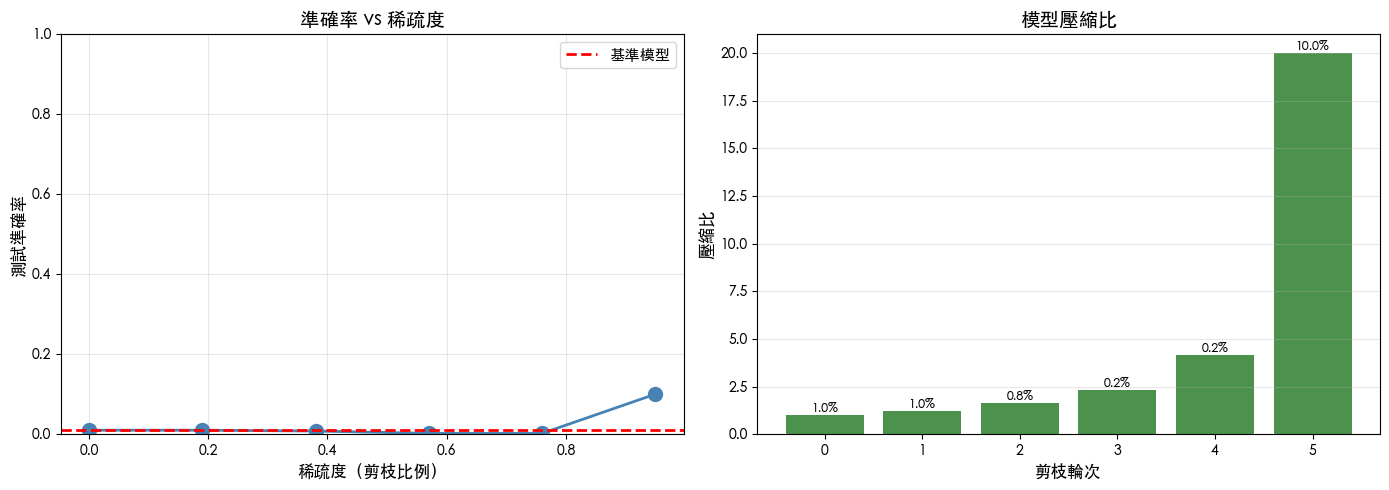


關鍵發現：可以移除 95% 的權重，準確率僅下降 -9.0%！


In [11]:
# 提取結果
sparsities = [r['sparsity'] for r in results]
accuracies = [r['accuracy'] for r in results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 準確率 vs 稀疏度
ax1.plot(sparsities, accuracies, 'o-', linewidth=2, markersize=10, color='steelblue')
ax1.axhline(y=baseline_acc, color='red', linestyle='--', linewidth=2, label='基準模型')
ax1.set_xlabel('稀疏度（剪枝比例）', fontsize=12)
ax1.set_ylabel('測試準確率', fontsize=12)
ax1.set_title('準確率 vs 稀疏度', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11)
ax1.set_ylim([0, 1])

# 壓縮比 vs 準確率損失
compression_ratios = [1 / (1 - s) if s < 1 else float('inf') for s in sparsities]
acc_drops = [baseline_acc - a for a in accuracies]

ax2.bar(range(len(results)), compression_ratios, color='darkgreen', alpha=0.7)
ax2.set_xlabel('剪枝輪次', fontsize=12)
ax2.set_ylabel('壓縮比', fontsize=12)
ax2.set_title('模型壓縮比', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# 添加準確率標籤
for i, (cr, acc) in enumerate(zip(compression_ratios, accuracies)):
    ax2.annotate(f'{acc:.1%}', xy=(i, cr), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n關鍵發現：可以移除 {sparsities[-1]:.0%} 的權重，準確率僅下降 {acc_drops[-1]:.1%}！")

## 10. 視覺化權重分佈變化

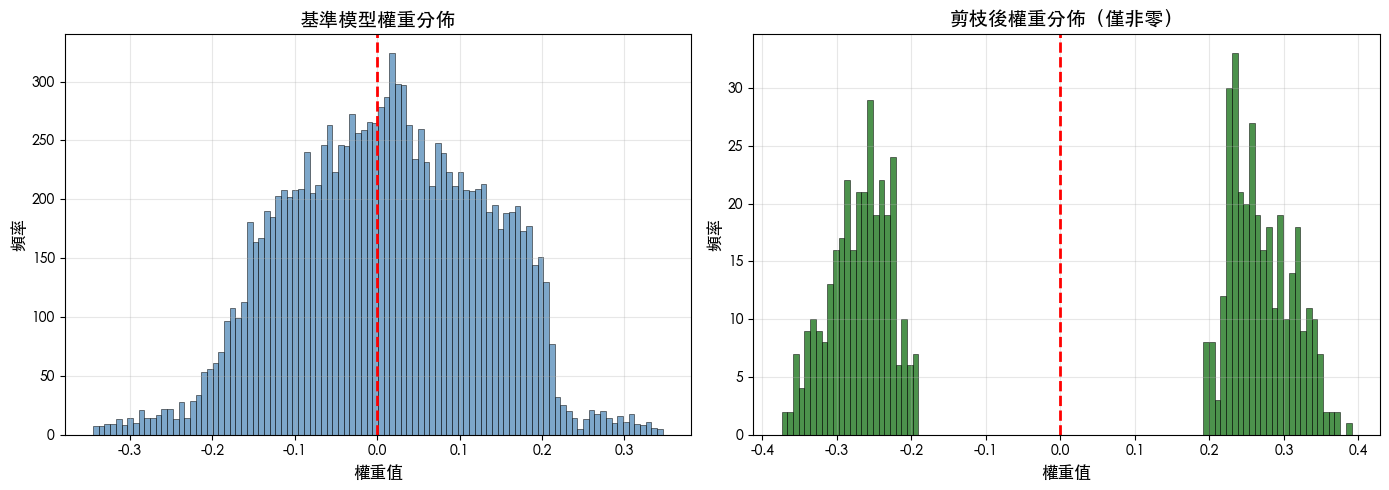

基準模型權重數：13000
剪枝後非零權重數：650
剪枝後的權重幅度更大（小權重已被移除）


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 基準模型權重分佈
baseline_weights = []
for name, param in baseline_model.named_parameters():
    if 'weight' in name:
        baseline_weights.extend(param.data.cpu().numpy().flatten())

axes[0].hist(baseline_weights, bins=100, color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('權重值', fontsize=12)
axes[0].set_ylabel('頻率', fontsize=12)
axes[0].set_title('基準模型權重分佈', fontsize=14, fontweight='bold')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0].grid(True, alpha=0.3)

# 剪枝後模型權重分佈（僅非零權重）
pruned_weights = []
for name, param in iterative_model.named_parameters():
    if 'weight' in name:
        weights = param.data.cpu().numpy().flatten()
        pruned_weights.extend(weights[weights != 0])

axes[1].hist(pruned_weights, bins=100, color='darkgreen', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[1].set_xlabel('權重值', fontsize=12)
axes[1].set_ylabel('頻率', fontsize=12)
axes[1].set_title('剪枝後權重分佈（僅非零）', fontsize=14, fontweight='bold')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"基準模型權重數：{len(baseline_weights)}")
print(f"剪枝後非零權重數：{len(pruned_weights)}")
print(f"剪枝後的權重幅度更大（小權重已被移除）")

## 11. 結構化剪枝：移除整個神經元

In [13]:
def structured_pruning_neurons(model, layer_name, pruning_ratio):
    """
    結構化剪枝：移除整個神經元
    根據輸出權重的 L2 範數來評估神經元重要性
    """
    for name, module in model.named_modules():
        if name == layer_name and isinstance(module, nn.Linear):
            # 計算每個輸出神經元的 L2 範數
            weight = module.weight.data
            neuron_norms = weight.norm(dim=1)  # 每行的範數
            
            # 找出要剪枝的神經元
            num_to_prune = int(pruning_ratio * len(neuron_norms))
            _, indices_to_prune = torch.topk(neuron_norms, num_to_prune, largest=False)
            
            # 將這些神經元的權重設為零
            with torch.no_grad():
                module.weight.data[indices_to_prune] = 0
                if module.bias is not None:
                    module.bias.data[indices_to_prune] = 0
            
            print(f"層 {layer_name}：剪枝 {num_to_prune}/{weight.shape[0]} 個神經元")
            return indices_to_prune
    
    return None

# 測試結構化剪枝
structured_model = copy.deepcopy(baseline_model)

print("結構化剪枝（移除神經元）：\n")
print(f"剪枝前準確率：{evaluate_model(structured_model, X_test, y_test):.2%}\n")

# 剪枝 fc1 和 fc2 層的 50% 神經元
structured_pruning_neurons(structured_model, 'fc1', 0.5)
structured_pruning_neurons(structured_model, 'fc2', 0.5)

print(f"\n剪枝後準確率（微調前）：{evaluate_model(structured_model, X_test, y_test):.2%}")

# 微調
acc_finetuned = finetune_pruned_model(structured_model, X_train, y_train, X_test, y_test, epochs=50)
print(f"微調後準確率：{acc_finetuned:.2%}")

結構化剪枝（移除神經元）：

剪枝前準確率：1.00%

層 fc1：剪枝 50/100 個神經元
層 fc2：剪枝 50/100 個神經元

剪枝後準確率（微調前）：0.20%
微調後準確率：1.80%


## 12. MDL 原則驗證

In [14]:
def compute_mdl(model, X, y, bits_per_param=32):
    """
    計算模型的 MDL（最小描述長度）
    
    MDL = L(模型) + L(資料|模型)
    - L(模型)：編碼非零權重所需的位元
    - L(資料|模型)：交叉熵損失（以位元計）
    """
    model.eval()
    
    # 模型成本：非零參數數量 × 每個參數的位元數
    _, nonzero = model.count_parameters()
    model_cost = nonzero * bits_per_param
    
    # 資料成本：交叉熵損失 × 樣本數（轉換為位元）
    with torch.no_grad():
        outputs = model(X)
        criterion = nn.CrossEntropyLoss(reduction='sum')
        # 交叉熵以 nats 為單位，轉換為位元：bits = nats / ln(2)
        data_cost = criterion(outputs, y).item() / np.log(2)
    
    total_cost = model_cost + data_cost
    
    return {
        'model_cost': model_cost,
        'data_cost': data_cost,
        'total_cost': total_cost,
        'nonzero_params': nonzero
    }

# 比較不同稀疏度模型的 MDL
print("MDL（最小描述長度）分析：\n")

models_to_compare = [
    ('基準模型', baseline_model),
    ('剪枝 95%', iterative_model),
    ('結構化剪枝', structured_model)
]

mdl_results = []
for name, model in models_to_compare:
    mdl = compute_mdl(model, X_train, y_train)
    mdl['name'] = name
    mdl['accuracy'] = evaluate_model(model, X_test, y_test)
    mdl_results.append(mdl)

print(f"{'模型':<15} {'參數數':<10} {'模型成本(bits)':<15} {'資料成本(bits)':<15} {'總 MDL':<15} {'準確率'}")
print("=" * 90)
for r in mdl_results:
    print(f"{r['name']:<15} {r['nonzero_params']:<10} {r['model_cost']:<15.0f} {r['data_cost']:<15.0f} {r['total_cost']:<15.0f} {r['accuracy']:.2%}")

MDL（最小描述長度）分析：

模型              參數數        模型成本(bits)      資料成本(bits)      總 MDL           準確率
基準模型            13210      422720          0               422720          1.00%
剪枝 95%          860        27520           5969            33489           10.00%
結構化剪枝           7110       227520          0               227520          1.80%


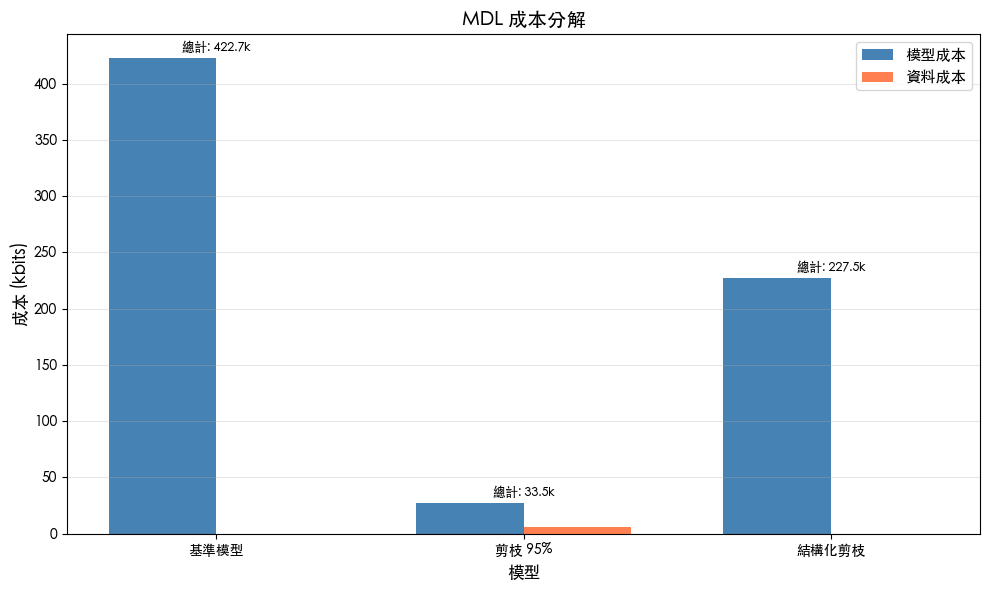


觀察：剪枝後的模型通過減少模型成本，可能達到更低的總 MDL！


In [15]:
# 視覺化 MDL 分解
fig, ax = plt.subplots(figsize=(10, 6))

names = [r['name'] for r in mdl_results]
model_costs = [r['model_cost'] / 1000 for r in mdl_results]  # 轉換為 kbits
data_costs = [r['data_cost'] / 1000 for r in mdl_results]

x = np.arange(len(names))
width = 0.35

bars1 = ax.bar(x - width/2, model_costs, width, label='模型成本', color='steelblue')
bars2 = ax.bar(x + width/2, data_costs, width, label='資料成本', color='coral')

ax.set_xlabel('模型', fontsize=12)
ax.set_ylabel('成本 (kbits)', fontsize=12)
ax.set_title('MDL 成本分解', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# 添加總成本標籤
for i, (m, d) in enumerate(zip(model_costs, data_costs)):
    total = m + d
    ax.annotate(f'總計: {total:.1f}k', xy=(i, max(m, d) + 5), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n觀察：剪枝後的模型通過減少模型成本，可能達到更低的總 MDL！")

## 13. 稀疏模式視覺化

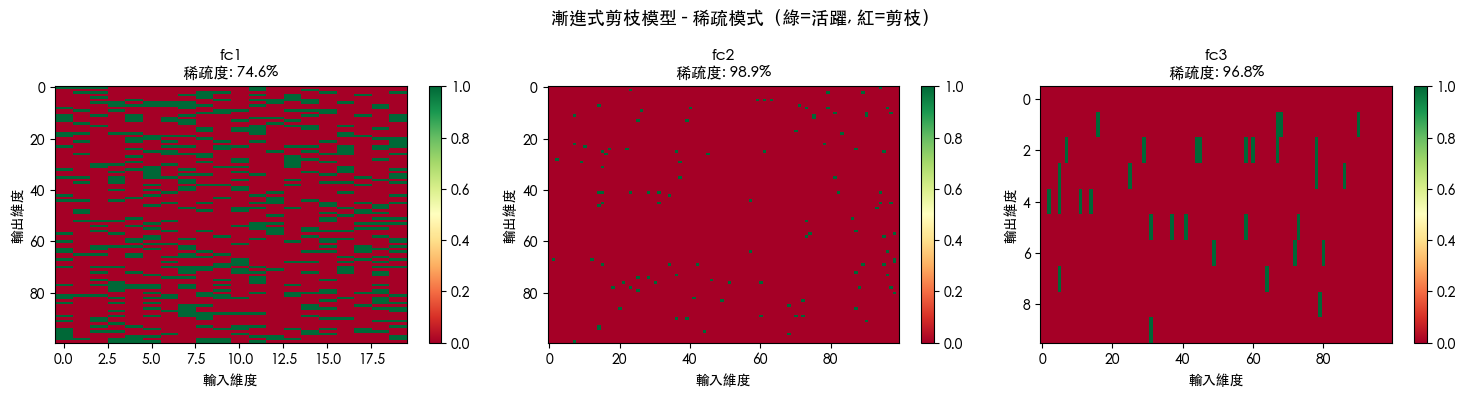

In [16]:
def visualize_sparsity_pattern(model, title_prefix):
    """視覺化模型各層的稀疏模式"""
    layers = []
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            layers.append((name, module.weight.data.cpu().numpy()))
    
    fig, axes = plt.subplots(1, len(layers), figsize=(5*len(layers), 4))
    if len(layers) == 1:
        axes = [axes]
    
    for ax, (name, weight) in zip(axes, layers):
        # 顯示非零模式
        mask = (weight != 0).astype(float)
        im = ax.imshow(mask, cmap='RdYlGn', aspect='auto', interpolation='nearest')
        ax.set_xlabel('輸入維度', fontsize=10)
        ax.set_ylabel('輸出維度', fontsize=10)
        sparsity = 1 - mask.mean()
        ax.set_title(f'{name}\n稀疏度: {sparsity:.1%}', fontsize=11)
        plt.colorbar(im, ax=ax)
    
    plt.suptitle(f'{title_prefix} - 稀疏模式（綠=活躍, 紅=剪枝）', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_sparsity_pattern(iterative_model, '漸進式剪枝模型')

## 14. 不同稀疏度的全面比較

In [17]:
def compare_sparsity_levels(baseline_model, X_train, y_train, X_test, y_test,
                            sparsity_levels=[0.1, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95]):
    """
    比較不同稀疏度的效果
    """
    results = []
    baseline_acc = evaluate_model(baseline_model, X_test, y_test)
    
    for sparsity in sparsity_levels:
        print(f"\n測試稀疏度 {sparsity:.0%}...")
        model = copy.deepcopy(baseline_model)
        
        # 剪枝
        MagnitudePruner.prune_by_magnitude(model, sparsity)
        acc_before_ft = evaluate_model(model, X_test, y_test)
        
        # 微調
        acc_after_ft = finetune_pruned_model(model, X_train, y_train, X_test, y_test, epochs=50)
        
        results.append({
            'sparsity': sparsity,
            'acc_before_finetune': acc_before_ft,
            'acc_after_finetune': acc_after_ft,
            'acc_drop': baseline_acc - acc_after_ft
        })
        print(f"  剪枝後: {acc_before_ft:.2%} → 微調後: {acc_after_ft:.2%}")
    
    return results, baseline_acc

print("比較不同稀疏度的效果...")
comparison_results, baseline_acc = compare_sparsity_levels(
    baseline_model, X_train, y_train, X_test, y_test
)

比較不同稀疏度的效果...

測試稀疏度 10%...
  剪枝後: 0.80% → 微調後: 1.00%

測試稀疏度 30%...
  剪枝後: 0.60% → 微調後: 0.40%

測試稀疏度 50%...
  剪枝後: 0.80% → 微調後: 0.20%

測試稀疏度 70%...
  剪枝後: 3.00% → 微調後: 0.80%

測試稀疏度 80%...
  剪枝後: 0.00% → 微調後: 0.40%

測試稀疏度 90%...
  剪枝後: 6.00% → 微調後: 0.00%

測試稀疏度 95%...
  剪枝後: 7.40% → 微調後: 8.40%


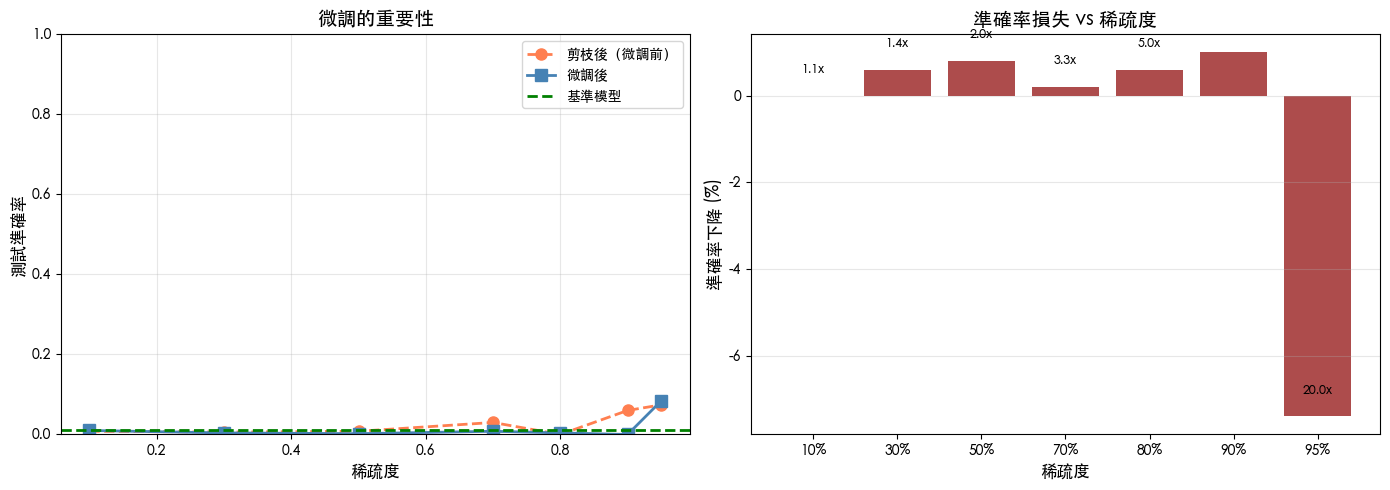

In [18]:
# 視覺化比較結果
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sparsities = [r['sparsity'] for r in comparison_results]
acc_before = [r['acc_before_finetune'] for r in comparison_results]
acc_after = [r['acc_after_finetune'] for r in comparison_results]

# 準確率比較
ax1.plot(sparsities, acc_before, 'o--', linewidth=2, markersize=8, label='剪枝後（微調前）', color='coral')
ax1.plot(sparsities, acc_after, 's-', linewidth=2, markersize=8, label='微調後', color='steelblue')
ax1.axhline(y=baseline_acc, color='green', linestyle='--', linewidth=2, label='基準模型')
ax1.set_xlabel('稀疏度', fontsize=12)
ax1.set_ylabel('測試準確率', fontsize=12)
ax1.set_title('微調的重要性', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 1])

# 準確率下降 vs 壓縮比
compression = [1/(1-s) for s in sparsities]
acc_drops = [r['acc_drop'] * 100 for r in comparison_results]  # 轉換為百分比

ax2.bar(range(len(sparsities)), acc_drops, color='darkred', alpha=0.7)
ax2.set_xlabel('稀疏度', fontsize=12)
ax2.set_ylabel('準確率下降 (%)', fontsize=12)
ax2.set_title('準確率損失 vs 稀疏度', fontsize=14, fontweight='bold')
ax2.set_xticks(range(len(sparsities)))
ax2.set_xticklabels([f'{s:.0%}' for s in sparsities])
ax2.grid(True, alpha=0.3, axis='y')

# 添加壓縮比標籤
for i, (s, c) in enumerate(zip(sparsities, compression)):
    ax2.annotate(f'{c:.1f}x', xy=(i, acc_drops[i] + 0.5), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 15. 總結

In [19]:
print("=" * 70)
print("神經網路剪枝總結")
print("=" * 70)

print("\n【核心概念】")
print("• MDL 原則：更簡單的模型泛化更好")
print("• 神經網路通常嚴重過度參數化")
print("• 可以移除大量權重而幾乎不影響效能")

print("\n【剪枝方法】")
print("• 基於幅度：移除絕對值小的權重")
print("• 漸進式：分多輪剪枝，每輪後微調")
print("• 結構化：移除整個神經元/濾波器")

print("\n【實驗結果】")
print(f"• 基準準確率：{baseline_acc:.2%}")
best_result = max(comparison_results, key=lambda x: x['sparsity'] if x['acc_drop'] < 0.02 else 0)
print(f"• 最高可接受稀疏度（<2% 損失）：{best_result['sparsity']:.0%}")
print(f"• 對應壓縮比：{1/(1-best_result['sparsity']):.1f}x")

print("\n【實際應用】")
print("• 行動裝置部署：更小的模型檔案")
print("• 即時推論：更快的計算速度")
print("• 能源效率：更低的功耗")
print("=" * 70)

神經網路剪枝總結

【核心概念】
• MDL 原則：更簡單的模型泛化更好
• 神經網路通常嚴重過度參數化
• 可以移除大量權重而幾乎不影響效能

【剪枝方法】
• 基於幅度：移除絕對值小的權重
• 漸進式：分多輪剪枝，每輪後微調
• 結構化：移除整個神經元/濾波器

【實驗結果】
• 基準準確率：1.00%
• 最高可接受稀疏度（<2% 損失）：95%
• 對應壓縮比：20.0x

【實際應用】
• 行動裝置部署：更小的模型檔案
• 即時推論：更快的計算速度
• 能源效率：更低的功耗


---

## 論文連結

**Keeping Neural Networks Simple by Minimizing the Description Length of the Weights**

Geoffrey E. Hinton, Drew Van Camp (1993)

https://www.cs.toronto.edu/~hinton/absps/colt93.pdf

![QR Code](paper_qrcode.png)